# Useful Imports

In [15]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path("..").resolve()))

# Load Training Results

In [ ]:
experiment_folder = "experiment_20260713_104836"
training_results = pickle.load(open(f"../outputs/{experiment_folder}/training_results.pkl", "rb"))

In [6]:
print(f"Training results loaded from experiment folder: {experiment_folder} with {len(training_results)} models.")
print(f"Trained models: {list(training_results.keys())}")

Training results loaded from experiment folder: experiment_20260713_104836 with 9 models.
Trained models: ['yolov8m-cls', 'yolov8l-cls', 'yolov8x-cls', 'yolo11m-cls', 'yolo11l-cls', 'yolo11x-cls', 'yolo26m-cls', 'yolo26l-cls', 'yolo26x-cls']


# Train/validation loss

In [16]:
training_losses = {
    "yolov8m-cls": [2.22419, 1.77568, 1.50677, 1.30697, 1.15323, 1.01537, 0.96943, 0.9098, 0.8167, 0.79599, 0.7913, 0.72658],
    "yolov8l-cls": [2.17448, 1.60299, 1.2721, 1.03116, 0.90072, 0.74887, 0.69894, 0.66681, 0.57558, 0.54245, 0.56436, 0.48887],
    "yolov8x-cls": [2.10096, 1.47506, 1.14385, 0.89844, 0.75376, 0.64489, 0.58526, 0.51762, 0.44207, 0.42884, 0.43777, 0.38235],
    "yolo11m-cls": [1.98521, 1.37323, 1.04308, 0.83487, 0.74669, 0.60031, 0.56475, 0.53798, 0.49115, 0.444, 0.45919, 0.41756],
    "yolo11l-cls": [1.9993, 1.35605, 1.02331, 0.81915, 0.69571, 0.5964, 0.56081, 0.52744, 0.44047, 0.43705, 0.43506, 0.3993],
    "yolo11x-cls": [2.04195, 1.27843, 0.8583, 0.68307, 0.58387, 0.45823, 0.38626, 0.35458, 0.31193, 0.30426, 0.30651, 0.22716],
    "yolo26m-cls": [2.01744, 1.395, 1.0808, 0.89438, 0.76159, 0.65913, 0.61438, 0.5679, 0.53983, 0.49887, 0.48315, 0.47753],
    "yolo26l-cls": [2.01627, 1.3841, 1.07253, 0.89003, 0.7824, 0.68109, 0.63107, 0.61575, 0.52557, 0.51331, 0.53272, 0.47077],
    "yolo26x-cls": [2.03436, 1.25324, 0.89929, 0.71652, 0.5921, 0.47975, 0.41399, 0.42837, 0.36106, 0.3511, 0.33484, 0.28519]
}

validation_losses = {
    "yolov8m-cls": [1.89626, 1.44937, 1.16499, 0.99297, 0.88039, 0.76089, 0.65836, 0.58109, 0.59026, 0.50999, 0.5952, 0.5449],
    "yolov8l-cls": [1.70833, 1.17153, 0.8611, 0.63953, 0.55251, 0.4603, 0.44279, 0.3375, 0.32811, 0.32985, 0.38819, 0.34249],
    "yolov8x-cls": [1.53907, 0.98144, 0.66099, 0.4892, 0.42605, 0.33423, 0.29867, 0.23775, 0.25007, 0.22581, 0.24073, 0.20901],
    "yolo11m-cls": [1.40856, 0.86236, 0.61833, 0.48033, 0.38541, 0.29129, 0.25948, 0.21152, 0.21154, 0.20282, 0.21462, 0.18612],
    "yolo11l-cls": [1.30134, 0.82797, 0.6411, 0.46647, 0.38258, 0.3411, 0.27906, 0.22974, 0.26742, 0.21307, 0.24163, 0.1997],
    "yolo11x-cls": [1.32671, 0.67678, 0.45101, 0.33006, 0.29842, 0.25869, 0.24492, 0.20402, 0.19386, 0.17873, 0.24821, 0.18287],
    "yolo26m-cls": [1.3884, 0.89931, 0.70754, 0.53945, 0.47144, 0.36482, 0.37947, 0.29974, 0.31082, 0.30316, 0.34018, 0.27882],
    "yolo26l-cls": [1.45126, 0.82921, 0.6514, 0.48671, 0.41402, 0.33075, 0.34664, 0.26684, 0.27363, 0.26262, 0.285, 0.24314],
    "yolo26x-cls": [1.31664, 0.71442, 0.44658, 0.31564, 0.27671, 0.20925, 0.20203, 0.16869, 0.17787, 0.15126, 0.18025, 0.15538]
}

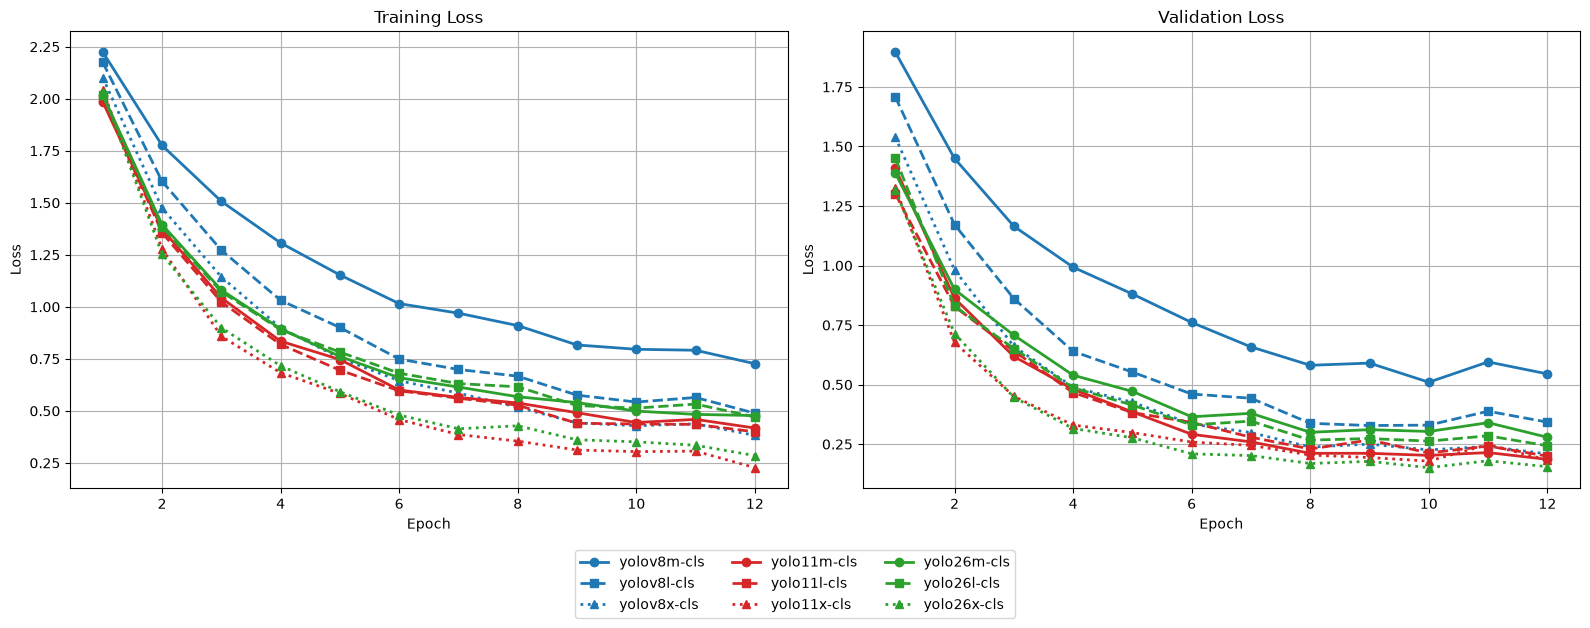

In [27]:
# Plots
colors = {
    "yolov8": "#1f77b4",   # Bleu
    "yolo11": "#d62728",   # Rouge
    "yolo26": "#2ca02c",   # Vert
}

linestyles = {
    "m": "-",
    "l": "--",
    "x": ":",
}

markers = {
    "m": "o",
    "l": "s",
    "x": "^"
}

epochs = range(1, 13)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Training loss
for model_name, losses in training_losses.items():
    if model_name.startswith("yolov8"):
        color = colors["yolov8"]
    elif model_name.startswith("yolo11"):
        color = colors["yolo11"]
    else:
        color = colors["yolo26"]

    if "m-cls" in model_name:
        linestyle = linestyles["m"]
        marker = markers["m"]
    elif "l-cls" in model_name:
        linestyle = linestyles["l"]
        marker = markers["l"]
    else:
        linestyle = linestyles["x"]
        marker = markers["x"]

    axes[0].plot(
        epochs,
        losses,
        label=model_name,
        color=color,
        linestyle=linestyle,
        marker=marker,
        linewidth=2,
    )

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Validation loss
for model_name, losses in validation_losses.items():
    if model_name.startswith("yolov8"):
        color = colors["yolov8"]
    elif model_name.startswith("yolo11"):
        color = colors["yolo11"]
    else:
        color = colors["yolo26"]

    if "m-cls" in model_name:
        linestyle = linestyles["m"]
        marker = markers["m"]
    elif "l-cls" in model_name:
        linestyle = linestyles["l"]
        marker = markers["l"]
    else:
        linestyle = linestyles["x"]
        marker = markers["x"]

    axes[1].plot(
        epochs,
        losses,
        label=model_name,
        color=color,
        linestyle=linestyle,
        marker=marker,
        linewidth=2,
    )

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# Validation and Test Accuracy

In [28]:
train_duration, validation_accuracy, test_accuracy = {}, {}, {}
for model_name, model_result in training_results.items():
    validation_accuracy[model_name] = model_result.val_metrics["accuracy"]
    test_accuracy[model_name] = model_result.test_metrics["accuracy"]
    train_duration[model_name] = model_result.time_taken

In [29]:
model_family = {
    "yolov8m-cls": "yolov8",
    "yolov8l-cls": "yolov8",
    "yolov8x-cls": "yolov8",
    "yolo11m-cls": "yolo11",
    "yolo11l-cls": "yolo11",
    "yolo11x-cls": "yolo11",
    "yolo26m-cls": "yolo26",
    "yolo26l-cls": "yolo26",
    "yolo26x-cls": "yolo26"
}

# Create a DataFrame to summarize the results
df = pd.DataFrame({
    "model": list(train_duration.keys()),
    "train_duration": list(train_duration.values()),
    "validation_accuracy": list(validation_accuracy.values()),
    "test_accuracy": list(test_accuracy.values()),
})

df["family"] = df["model"].map(model_family)
df["size"] = df["model"].str.extract(r"(m|l|x)-cls")
df

,model,train_duration,validation_accuracy,test_accuracy,family,size
0,yolov8m-cls,643.337252,0.860606,0.872727,yolov8,m
1,yolov8l-cls,798.160813,0.921212,0.909091,yolov8,l
2,yolov8x-cls,1017.946029,0.945455,0.957576,yolov8,x
3,yolo11m-cls,656.432846,0.939394,0.915152,yolo11,m
4,yolo11l-cls,731.768595,0.933333,0.939394,yolo11,l
5,yolo11x-cls,880.142629,0.951515,0.969697,yolo11,x
6,yolo26m-cls,657.736852,0.927273,0.933333,yolo26,m
7,yolo26l-cls,734.271256,0.933333,0.939394,yolo26,l
8,yolo26x-cls,881.361720,0.957576,0.957576,yolo26,x


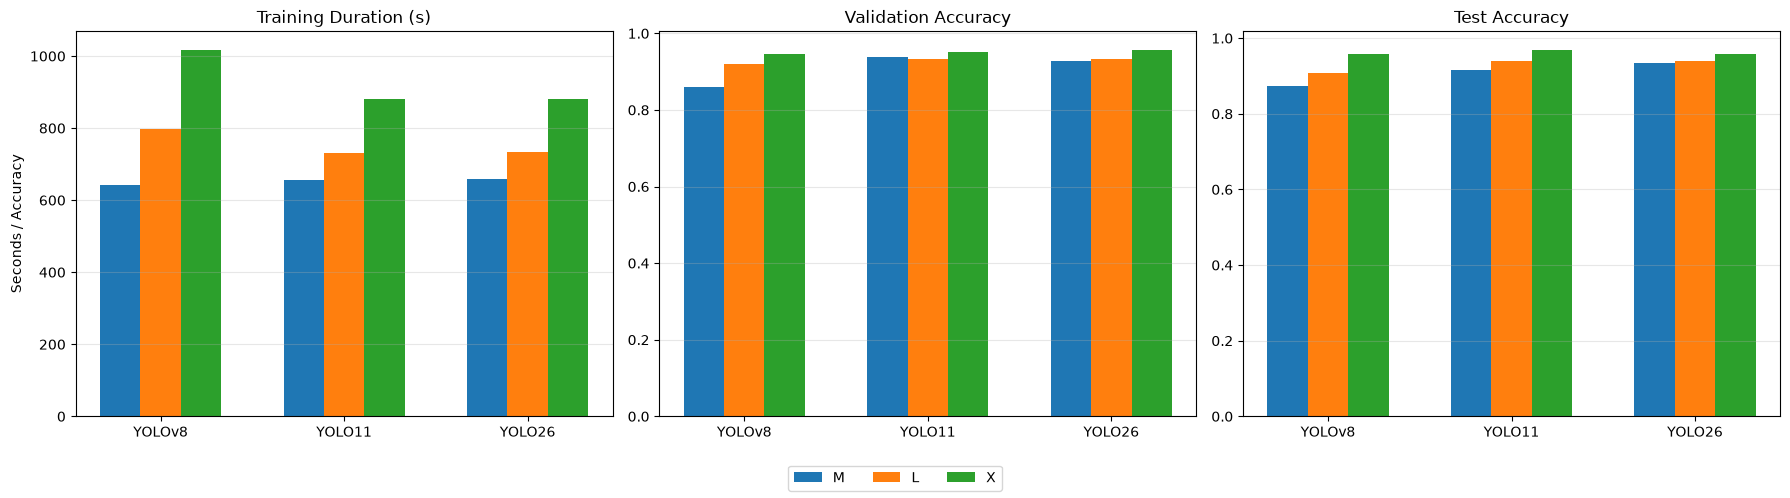

In [33]:
import matplotlib.pyplot as plt
import numpy as np

families = ["yolov8", "yolo11", "yolo26"]
sizes = ["m", "l", "x"]

metrics = {
    "Training Duration (s)": train_duration,
    "Validation Accuracy": validation_accuracy,
    "Test Accuracy": test_accuracy,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

width = 0.22
x = np.arange(len(families))

colors = {
    "m": "tab:blue",
    "l": "tab:orange",
    "x": "tab:green",
}

for ax, (metric_name, metric_values) in zip(axes, metrics.items()):

    for i, size in enumerate(sizes):

        values = []

        for family in families:
            model_name = f"{family}{size}-cls"
            values.append(metric_values[model_name])

        ax.bar(
            x + (i - 1) * width,
            values,
            width,
            label=size.upper(),
            color=colors[size],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(["YOLOv8", "YOLO11", "YOLO26"])
    ax.set_title(metric_name)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Seconds / Accuracy")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()